
# Bipartite Kuramoto Clustering — `script.ipynb`

Pipeline por **bloques** para clustering con **Kuramoto bipartito**:
1) Matriz N×M (aleatoria o CSV local)  
2) Normalización [0,1]  
3) Multiplicar por 2π → fases Θ  
4) Promedios por fila/columna → fases iniciales  
5) Integración Kuramoto (RK4, ω=0, K uniforme)  
6) Afinidades (PLV): cruzada, intra-filas, intra-columnas  
7) Coherencia global y por partición, resumen y gráfico  

**Bloque extra:** clustering de **ELEMENTOS (i,j)** de `A_cross` para etiquetar coordenadas de la matriz original `X`.


In [1]:

# ==============================
# Configuración general
# ==============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Dimensiones (solo si USE_CSV=False)
N = 150
M = 100

# Rango enteros aleatorios (inclusivo)
RAND_MIN = 0
RAND_MAX = 100

# Semilla
SEED = 42

# Acoplamiento uniforme
K = 1.0

# Integración (RK4)
dt = 0.01
T_total = 5.0
NUM_STEPS = int(T_total / dt)

# Entrada por CSV (misma carpeta del notebook)
USE_CSV = True     # Cambiar a True para cargar CSV
CSV_NAME = None     # Si None, se detecta el primer .csv
CSV_DELIMITER = ","

# Guardado
SAVE_PREFIX = "kuramoto_bipartito"
SAVE_CSV = True
SAVE_PNG = True

np.random.seed(SEED)
print(f"Config -> N={N}, M={M}, RAND=[{RAND_MIN},{RAND_MAX}], K={K}, dt={dt}, T={T_total}s")


Config -> N=150, M=100, RAND=[0,100], K=1.0, dt=0.01, T=5.0s


In [2]:
# ==============================
# Cargar archivo CSV / OTUS desde ruta
# ==============================
import pandas as pd
import numpy as np
from pathlib import Path

# Ruta del archivo (TÚ LA DEFINES AQUÍ)
# Ejemplos válidos:
# FILE_PATH = r"D:\datos\otu_data.otus"
# FILE_PATH = "./data/tabla.csv"
# FILE_PATH = "/home/user/matrices/matriz.otus"

FILE_PATH = r"D:\Proyectos\Proyectos Python\Clustering_Microbiota\Datos\otu_data.otus"   # <<< MODIFÍCALA AQUÍ


def load_matrix_from_path(path):
    """
    Carga una matriz numérica desde un archivo .csv o .otus.
    La ruta debe ser absoluta o relativa.
    """
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"No existe el archivo: {path}")

    ext = path.suffix.lower()

    if ext == ".csv":
        df = pd.read_csv(path, delimiter=",")
    elif ext == ".otus":
        df = pd.read_csv(path, sep="\t")  # Formato típico OTU
    else:
        raise ValueError(f"Formato no soportado: {ext}. Usa .csv o .otus")

    # Mantener únicamente columnas numéricas
    df_numeric = df.select_dtypes(include=[np.number])

    if df_numeric.empty:
        raise ValueError(f"El archivo {path.name} no contiene columnas numéricas.")

    return df_numeric.values.astype(float)


# ==============================
# Carga de la matriz
# ==============================
X = load_matrix_from_path(FILE_PATH)
print(f"✅ Archivo cargado: {FILE_PATH} → matriz {X.shape}")


✅ Archivo cargado: D:\Proyectos\Proyectos Python\Clustering_Microbiota\Datos\otu_data.otus → matriz (441, 4738)


ALPHA (significancia): 0.05
N total: 2089458
Ceros:   1984038  (94.95%)
Positivos: 105420  (5.05%)
Min: 0, Max: 6.071e+04
Columnas totales: 4738
Columnas totalmente cero: 18 (0.38%)
Índices de columnas todo-cero (0-based): [1862, 2422, 3116, 3174, 3182, 3249, 3342, 3432, 3497, 3540, 3673, 3746, 3798, 4186, 4283, 4578, 4646, 4655]


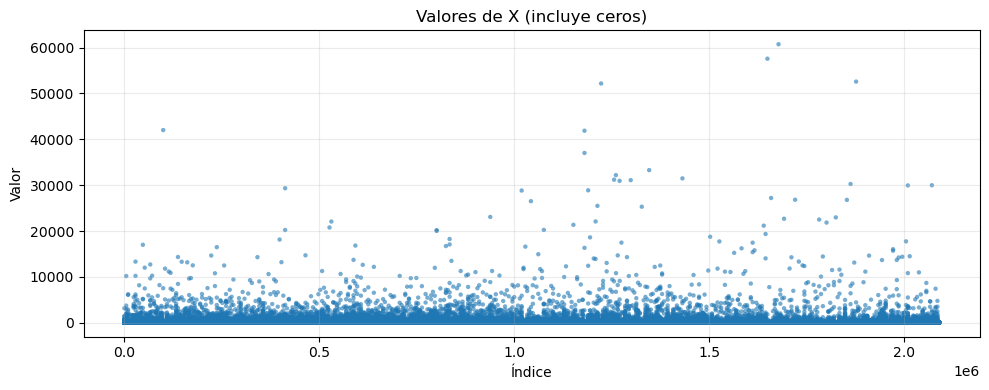

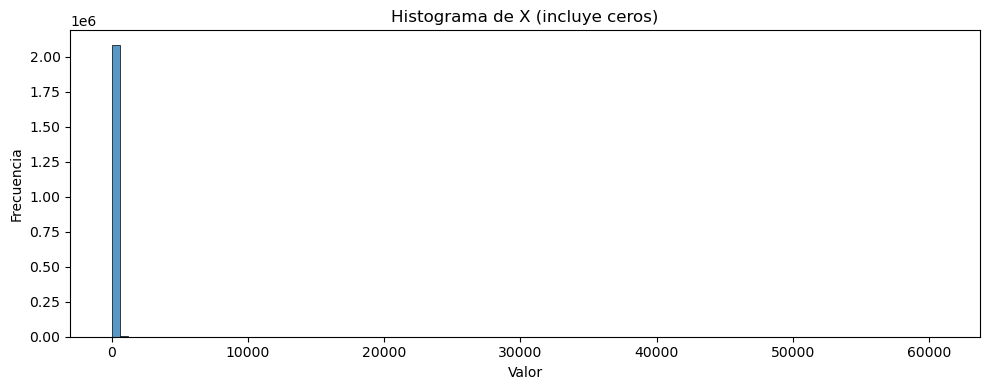

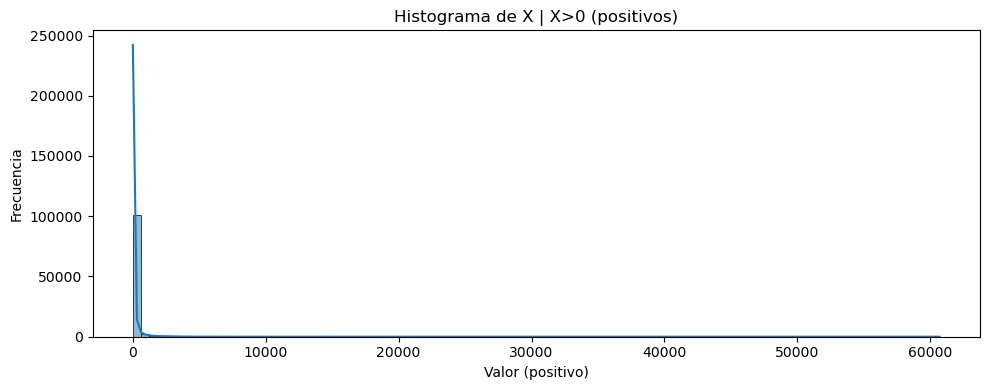

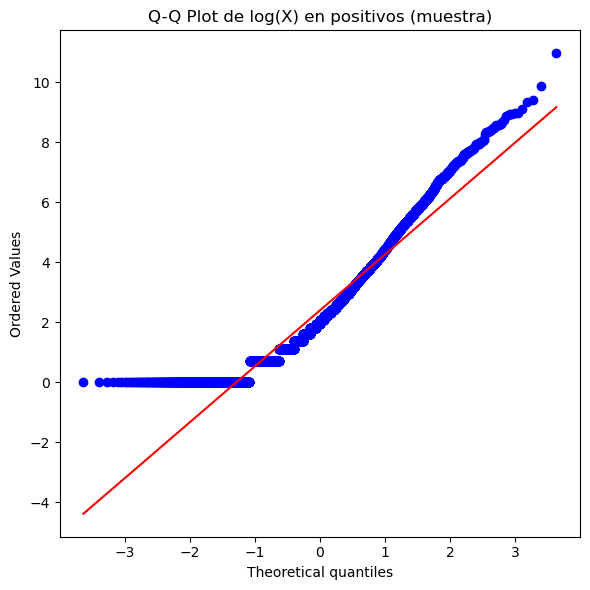


Normalidad de log(X>0) (Shapiro-Wilk, muestra):
  estadístico = 0.9284, p = 9.301e-44
  Decisión (α=0.05): SE rechaza normalidad (p < α).

Normalidad de log(X>0) (Anderson-Darling, muestra):
  AD stat = 92.7103
  crit @ 15.0%: 0.5760
  crit @ 10.0%: 0.6550
  crit @  5.0%: 0.7860
  crit @  2.5%: 0.9170
  crit @  1.0%: 1.0910
  Decisión (≈α=0.05, usando crítico 5.0%): SE rechaza normalidad (AD > crit).

Comparación SOLO positivos (componente continuo):


,modelo_pos,AIC_pos,BIC_pos
0,pos_lognormal,179577.281987,179593.088962
1,pos_gamma,196234.271480,196250.078455
2,pos_expon,235508.135709,235516.039197


➜ Mejor en positivos por AIC: pos_lognormal

Comparación TOTAL (hurdle: incluye masa en cero + positivos):


,modelo_total,AIC_total,BIC_total,pi_hat,params
0,hurdle_lognormal,505334.383349,505371.915373,0.949547,"(2.4268557731267992, 1.944435505134629, 0.0, 1..."
1,hurdle_gamma,522635.298912,522672.830937,0.949547,"(0.2751332453867606, 0.0, 522.8168620545839)"
2,hurdle_expon,563651.001431,563676.022780,0.949547,"(0.0, 143.8443)"


➜ Mejor modelo TOTAL por AIC: hurdle_lognormal


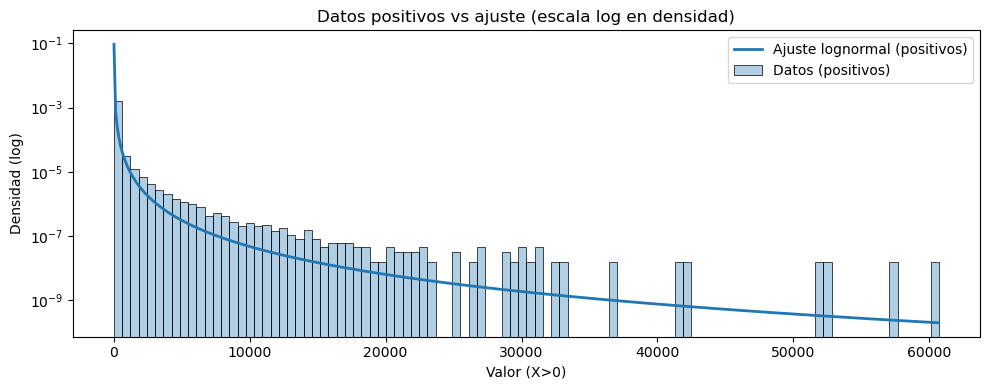

In [6]:
# =========================================
# Bloque: Análisis de distribución de X (con 90% ceros)
#   -> Modelo HURDLE (masa en 0) + ajuste en positivos
#   -> (MOD) Reporta cuántas COLUMNAS son totalmente cero
#   -> (MOD) Parámetro ALPHA (significancia) para decisión en pruebas de normalidad
# =========================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import shapiro, probplot
from scipy.stats import lognorm, gamma, expon
from scipy.stats import anderson
import pandas as pd

# -----------------------------
# 0. Parámetros
# -----------------------------
ALPHA = 0.05   # <-- cambia aquí (ej: 0.01, 0.10, etc.)

# -----------------------------
# 1. Preparar datos
# -----------------------------
X_arr = np.asarray(X, dtype=float)
valores = X_arr.flatten()
n = len(valores)

n0 = int(np.sum(valores == 0))
npos = int(np.sum(valores > 0))
pi_hat = n0 / n

# ---- Columnas totalmente cero ----
if X_arr.ndim == 2:
    cols_all_zero_mask = np.all(X_arr == 0, axis=0)
    n_cols_all_zero = int(np.sum(cols_all_zero_mask))
    n_cols = int(X_arr.shape[1])
    cols_all_zero_idx = np.where(cols_all_zero_mask)[0]
else:
    n_cols_all_zero = None
    n_cols = None
    cols_all_zero_idx = None

print(f"ALPHA (significancia): {ALPHA}")
print(f"N total: {n}")
print(f"Ceros:   {n0}  ({100*pi_hat:.2f}%)")
print(f"Positivos: {npos}  ({100*(1-pi_hat):.2f}%)")
print(f"Min: {valores.min():.4g}, Max: {valores.max():.4g}")

if X_arr.ndim == 2:
    print(f"Columnas totales: {n_cols}")
    print(f"Columnas totalmente cero: {n_cols_all_zero} ({100*n_cols_all_zero/max(n_cols,1):.2f}%)")
    if n_cols_all_zero > 0:
        print(f"Índices de columnas todo-cero (0-based): {cols_all_zero_idx.tolist()}")

valores_pos = valores[valores > 0]

# -----------------------------
# 2) Visuales
# -----------------------------
plt.figure(figsize=(10, 4))
plt.scatter(np.arange(n), valores, s=10, alpha=0.6, edgecolor="none")
plt.title("Valores de X (incluye ceros)")
plt.xlabel("Índice")
plt.ylabel("Valor")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
sns.histplot(valores, bins=100, kde=False)
plt.title("Histograma de X (incluye ceros)")
plt.xlabel("Valor")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

if npos > 0:
    plt.figure(figsize=(10, 4))
    sns.histplot(valores_pos, bins=100, kde=True)
    plt.title("Histograma de X | X>0 (positivos)")
    plt.xlabel("Valor (positivo)")
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

# -----------------------------
# 3) Normalidad SOLO en positivos (log(X>0))
#    -> decisiones usando ALPHA
# -----------------------------
if npos == 0:
    print("⚠ No hay valores positivos. No tiene sentido ajustar lognormal/gamma/expon.")
else:
    rng = np.random.default_rng(42)
    sample_size = min(npos, 5000)
    muestra = rng.choice(valores_pos, size=sample_size, replace=False)
    log_vals = np.log(muestra)

    plt.figure(figsize=(6, 6))
    probplot(log_vals, dist="norm", plot=plt)
    plt.title("Q-Q Plot de log(X) en positivos (muestra)")
    plt.tight_layout()
    plt.show()

    # Shapiro-Wilk
    stat, p = shapiro(log_vals)
    print("\nNormalidad de log(X>0) (Shapiro-Wilk, muestra):")
    print(f"  estadístico = {stat:.4f}, p = {p:.4g}")
    if p >= ALPHA:
        print(f"  Decisión (α={ALPHA}): NO se rechaza normalidad (p ≥ α).")
    else:
        print(f"  Decisión (α={ALPHA}): SE rechaza normalidad (p < α).")

    # Anderson-Darling (devuelve críticos en niveles fijos)
    ad = anderson(log_vals, dist="norm")
    print("\nNormalidad de log(X>0) (Anderson-Darling, muestra):")
    print(f"  AD stat = {ad.statistic:.4f}")

    # Elegir el crítico más cercano a ALPHA (en %)
    alpha_pct = 100 * ALPHA
    levels = np.asarray(ad.significance_level, dtype=float)  # ej: [15, 10, 5, 2.5, 1]
    crits  = np.asarray(ad.critical_values, dtype=float)

    idx_near = int(np.argmin(np.abs(levels - alpha_pct)))
    level_used = float(levels[idx_near])
    crit_used  = float(crits[idx_near])

    for sl, cv in zip(levels, crits):
        print(f"  crit @ {sl:4.1f}%: {cv:.4f}")

    # Regla: rechazar si AD_stat > crit(al nivel elegido)
    if ad.statistic > crit_used:
        print(f"  Decisión (≈α={ALPHA}, usando crítico {level_used}%): SE rechaza normalidad (AD > crit).")
    else:
        print(f"  Decisión (≈α={ALPHA}, usando crítico {level_used}%): NO se rechaza normalidad (AD ≤ crit).")

# -----------------------------
# 4) Comparación de MODELOS HURDLE por AIC/BIC
# -----------------------------
def aic(ll, k):
    return 2*k - 2*ll

def bic(ll, k, n):
    return np.log(n)*k - 2*ll

def loglik_hurdle(pi_hat, ll_pos, n0, npos):
    pi_hat = float(np.clip(pi_hat, 1e-12, 1 - 1e-12))
    return n0*np.log(pi_hat) + npos*np.log(1.0 - pi_hat) + ll_pos

def fit_ll_lognorm(data_pos):
    sigma, loc, scale = lognorm.fit(data_pos, floc=0)
    ll = np.sum(lognorm.logpdf(data_pos, sigma, loc=loc, scale=scale))
    mu = float(np.log(scale))
    return float(ll), (mu, float(sigma), float(loc), float(scale))

def fit_ll_gamma(data_pos):
    a, loc, scale = gamma.fit(data_pos, floc=0)
    ll = np.sum(gamma.logpdf(data_pos, a, loc=loc, scale=scale))
    return float(ll), (float(a), float(loc), float(scale))

def fit_ll_expon(data_pos):
    loc, scale = expon.fit(data_pos, floc=0)
    ll = np.sum(expon.logpdf(data_pos, loc=loc, scale=scale))
    return float(ll), (float(loc), float(scale))

MAX_FIT = 20000
if npos > 0:
    rng = np.random.default_rng(123)
    data_fit = valores_pos if npos <= MAX_FIT else rng.choice(valores_pos, size=MAX_FIT, replace=False)

    models = {}
    ll_pos, params = fit_ll_lognorm(data_fit); models["pos_lognormal"] = {"ll": ll_pos, "k": 2, "params": params}
    ll_pos, params = fit_ll_gamma(data_fit);   models["pos_gamma"]     = {"ll": ll_pos, "k": 2, "params": params}
    ll_pos, params = fit_ll_expon(data_fit);   models["pos_expon"]     = {"ll": ll_pos, "k": 1, "params": params}

    rows_pos = []
    for name, info in models.items():
        rows_pos.append({
            "modelo_pos": name,
            "AIC_pos": aic(info["ll"], info["k"]),
            "BIC_pos": bic(info["ll"], info["k"], len(data_fit)),
        })

    df_pos = pd.DataFrame(rows_pos).sort_values("AIC_pos")
    print("\nComparación SOLO positivos (componente continuo):")
    display(df_pos)
    best_pos = df_pos.iloc[0]["modelo_pos"]
    print(f"➜ Mejor en positivos por AIC: {best_pos}")

    data_fit_all = valores_pos if npos <= MAX_FIT else rng.choice(valores_pos, size=MAX_FIT, replace=False)

    total_rows = []

    ll_pos_all, params_ln = fit_ll_lognorm(data_fit_all)
    ll_total_ln = loglik_hurdle(pi_hat, ll_pos_all, n0=n0, npos=len(data_fit_all))
    total_rows.append({"modelo_total":"hurdle_lognormal","AIC_total":aic(ll_total_ln,3),"BIC_total":bic(ll_total_ln,3,n0+len(data_fit_all)),"pi_hat":pi_hat,"params":params_ln})

    ll_pos_all, params_g = fit_ll_gamma(data_fit_all)
    ll_total_g = loglik_hurdle(pi_hat, ll_pos_all, n0=n0, npos=len(data_fit_all))
    total_rows.append({"modelo_total":"hurdle_gamma","AIC_total":aic(ll_total_g,3),"BIC_total":bic(ll_total_g,3,n0+len(data_fit_all)),"pi_hat":pi_hat,"params":params_g})

    ll_pos_all, params_e = fit_ll_expon(data_fit_all)
    ll_total_e = loglik_hurdle(pi_hat, ll_pos_all, n0=n0, npos=len(data_fit_all))
    total_rows.append({"modelo_total":"hurdle_expon","AIC_total":aic(ll_total_e,2),"BIC_total":bic(ll_total_e,2,n0+len(data_fit_all)),"pi_hat":pi_hat,"params":params_e})

    df_total = pd.DataFrame(total_rows).sort_values("AIC_total")
    print("\nComparación TOTAL (hurdle: incluye masa en cero + positivos):")
    display(df_total)

    best_total = df_total.iloc[0]["modelo_total"]
    print(f"➜ Mejor modelo TOTAL por AIC: {best_total}")

    # Curva ajustada vs histograma (solo positivos) para el mejor total
    best_name = str(best_total)
    xgrid = np.linspace(valores_pos.min(), valores_pos.max(), 500)

    plt.figure(figsize=(10, 4))
    sns.histplot(valores_pos, bins=100, stat="density", alpha=0.35, label="Datos (positivos)")
    if best_name == "hurdle_lognormal":
        mu, sigma, loc, scale = df_total.iloc[0]["params"]
        pdf = lognorm.pdf(xgrid, sigma, loc=loc, scale=scale)
        plt.plot(xgrid, pdf, linewidth=2, label="Ajuste lognormal (positivos)")
    elif best_name == "hurdle_gamma":
        a, loc, scale = df_total.iloc[0]["params"]
        pdf = gamma.pdf(xgrid, a, loc=loc, scale=scale)
        plt.plot(xgrid, pdf, linewidth=2, label="Ajuste gamma (positivos)")
    else:
        loc, scale = df_total.iloc[0]["params"]
        pdf = expon.pdf(xgrid, loc=loc, scale=scale)
        plt.plot(xgrid, pdf, linewidth=2, label="Ajuste expon (positivos)")

    plt.yscale("log")
    plt.title("Datos positivos vs ajuste (escala log en densidad)")
    plt.xlabel("Valor (X>0)")
    plt.ylabel("Densidad (log)")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [5]:

# ==============================
# Bloque 2: Normalización [0,1]
# ==============================
X_min = float(np.min(X))
X_max = float(np.max(X))
if X_max == X_min:
    X_norm = np.ones_like(X)
else:
    X_norm = (X - X_min) / (X_max - X_min)

print(f"Normalización: min={X_min:.6g}, max={X_max:.6g}")
print(f"Rango X_norm -> [{X_norm.min():.6f}, {X_norm.max():.6f}]")


Normalización: min=0, max=60711
Rango X_norm -> [0.000000, 1.000000]


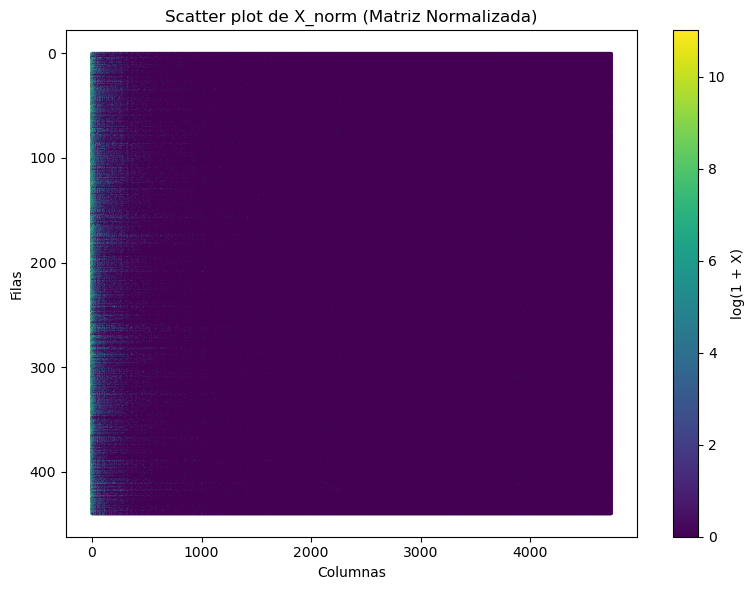

In [6]:
# ==============================
# Bloque 3: Gráfico de puntos (scatter) de X_norm
# ==============================
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 6))

# Si es vector 1D → puntos simples
if X_norm.ndim == 1:
    plt.scatter(np.arange(len(X_norm)), X_norm, s=25)
    plt.title("Scatter plot de X_norm (Vector Normalizado)")
    plt.xlabel("Índice")
    plt.ylabel("Valor Normalizado [0,1]")

# Si es matriz 2D → puntos por posición
elif X_norm.ndim == 2:
    filas, cols = X_norm.shape

    # Generar coordenadas de cada punto
    xs, ys = np.meshgrid(np.arange(cols), np.arange(filas))

    plt.scatter(xs.flatten(), ys.flatten(),
            c=np.log1p(X), cmap="viridis", s=1)

    plt.title("Scatter plot de X_norm (Matriz Normalizada)")
    plt.xlabel("Columnas")
    plt.ylabel("Filas")
    plt.gca().invert_yaxis()  # solo visual, opcional




else:
    raise ValueError("X_norm debe ser 1D o 2D.")

plt.colorbar(label="log(1 + X)")
plt.tight_layout()
plt.show()


In [7]:

# ==============================
# Bloque 3: Multiplicar por π
# ==============================
TWO_PI = np.pi
Theta = TWO_PI * X_norm   # fases base (N x M)
print("Theta lista. Ejemplo [0,0]:", float(Theta[0,0]))


Theta lista. Ejemplo [0,0]: 0.018318324510727655


In [8]:
# ==============================
# Bloque 4: Media circular por fila y columna (promedio natural en S^1)
# ==============================
import numpy as np

def wrap_2pi(angle):
    return np.mod(angle, TWO_PI)

def circular_mean(angles, axis):
    """
    Media circular en S^1:
        mean_angle = arg( mean( exp(i*theta) ) )
    Devuelve ángulos en [0, π).
    """
    Z = np.exp(1j * angles)                 # convierte a círculo unitario
    mZ = np.mean(Z, axis=axis)              # promedio complejo
    mean_angle = np.angle(mZ)               # arg en (-π, π]
    return wrap_2pi(mean_angle)

# Media circular por fila (N,) y por columna (M,)
phi0 = circular_mean(Theta, axis=1)   # N,
psi0 = circular_mean(Theta, axis=0)   # M,

print("Fases iniciales (media circular S^1):")
print("phi0 (N) ->", phi0.shape, "  rango:[", float(phi0.min()), ",", float(phi0.max()), "]")
print("psi0 (M) ->", psi0.shape, "  rango:[", float(psi0.min()), ",", float(psi0.max()), "]")


Fases iniciales (media circular S^1):
phi0 (N) -> (441,)   rango:[ 4.004581118476664e-05 , 0.0011018943292485824 ]
psi0 (M) -> (4738,)   rango:[ 0.0 , 0.12131688969806405 ]


In [9]:

# ==============================
# Bloque 5: Kuramoto bipartito (RK4)
# ==============================
# dφ_i/dt = (K / M) * Σ_j W_ij * sin(ψ_j - φ_i)
# dψ_j/dt = (K / N) * Σ_i W_ij * sin(φ_i - ψ_j)
# ω = 0, W = X_norm (pre-2π)

# W = X_norm[np.ix_(rows_keep, cols_keep)].copy()
W = X_norm.copy()

def kuramoto_rhs(phi, psi, W, K):
    Nr = phi.shape[0]
    Mc = psi.shape[0]
    phi_col = phi[:, None]   # N x 1
    psi_row = psi[None, :]   # 1 x M

    sin_term_rows = np.sin(psi_row - phi_col)  # N x M
    dphi = (K / max(1, Mc)) * np.sum(W * sin_term_rows, axis=1)

    sin_term_cols = np.sin(phi_col - psi_row)  # N x M
    dpsi = (K / max(1, Nr)) * np.sum(W * sin_term_cols, axis=0)
    return dphi, dpsi

def rk4_step(phi, psi, dt, W, K):
    k1_phi, k1_psi = kuramoto_rhs(phi, psi, W, K)
    k2_phi, k2_psi = kuramoto_rhs(phi + 0.5 * dt * k1_phi, psi + 0.5 * dt * k1_psi, W, K)
    k3_phi, k3_psi = kuramoto_rhs(phi + 0.5 * dt * k2_phi, psi + 0.5 * dt * k2_psi, W, K)
    k4_phi, k4_psi = kuramoto_rhs(phi + dt * k3_phi, psi + dt * k3_psi, W, K)

    phi_next = phi + (dt / 6.0) * (k1_phi + 2*k2_phi + 2*k3_phi + k4_phi)
    psi_next = psi + (dt / 6.0) * (k1_psi + 2*k2_psi + 2*k3_psi + k4_psi)
    return np.mod(phi_next, TWO_PI), np.mod(psi_next, TWO_PI)

phi = phi0.copy()
psi = psi0.copy()

traj_phi = np.empty((NUM_STEPS, phi.size), dtype=float)
traj_psi = np.empty((NUM_STEPS, psi.size), dtype=float)

for t in range(NUM_STEPS):
    traj_phi[t, :] = phi
    traj_psi[t, :] = psi
    phi, psi = rk4_step(phi, psi, dt, W, K)

print(f"Integración completada: pasos={NUM_STEPS}, dt={dt}, T={T_total}s")


Integración completada: pasos=500, dt=0.01, T=5.0s


In [10]:

# ==============================
# Bloque 6: Matrices de afinidad (PLV)
# ==============================
def plv_matrices(traj_phi, traj_psi):
    Z_rows = np.exp(1j * traj_phi)  # T x N
    Z_cols = np.exp(1j * traj_psi)  # T x M
    Tsteps = traj_phi.shape[0]

    A_cross = np.abs((Z_rows.conj().T @ Z_cols) / Tsteps)  # N x M
    A_rows  = np.abs((Z_rows.conj().T @ Z_rows) / Tsteps)  # N x N
    A_cols  = np.abs((Z_cols.conj().T @ Z_cols) / Tsteps)  # M x M
    return A_cross, A_rows, A_cols

A_cross, A_rows, A_cols = plv_matrices(traj_phi, traj_psi)

print("Afinidades listas:")
print("A_cross (N x M):", A_cross.shape, "  rango:[", float(A_cross.min()), ",", float(A_cross.max()), "]")
print("A_rows  (N x N):", A_rows.shape)
print("A_cols  (M x M):", A_cols.shape)

if SAVE_CSV:
    pd.DataFrame(A_cross).to_csv(f"{SAVE_PREFIX}_A_cross.csv", index=False)
    pd.DataFrame(A_rows).to_csv(f"{SAVE_PREFIX}_A_rows.csv", index=False)
    pd.DataFrame(A_cols).to_csv(f"{SAVE_PREFIX}_A_cols.csv", index=False)
    print("Guardado CSV de afinidades.")


Afinidades listas:
A_cross (N x M): (441, 4738)   rango:[ 0.9999759432272813 , 0.9999999999999719 ]
A_rows  (N x N): (441, 441)
A_cols  (M x M): (4738, 4738)
Guardado CSV de afinidades.


In [14]:
# ==============================
# Bloque 7: Prueba determinista matriz de afinidad
# ==============================

def run_once_get_Across(phi_init, psi_init):
    phi = phi_init.copy(); psi = psi_init.copy()
    traj_phi = np.empty((NUM_STEPS, phi.size), float)
    traj_psi = np.empty((NUM_STEPS, psi.size), float)
    for t in range(NUM_STEPS):
        traj_phi[t] = phi; traj_psi[t] = psi
        phi, psi = rk4_step(phi, psi, dt, W_base, K)
    A_cross, _, _ = plv_matrices(traj_phi, traj_psi)
    return A_cross

A0 = run_once_get_Across(phi0, psi0)
A1 = run_once_get_Across(phi0, psi0)
print("rel_diff A_cross eps=0:", np.linalg.norm(A1-A0,'fro')/(np.linalg.norm(A0,'fro')+1e-12))


rel_diff A_cross eps=0: 0.0


In [15]:
# ==============================
# Bloque 7.1: Prueba Estabilidad matriz de afinidad
# ==============================

A_ref = run_once_get_Across(phi0, psi0)
deltas = []
for run in range(5):
    dphi = rng.uniform(-0.01, 0.01, size=phi0.shape)
    dpsi = rng.uniform(-0.01, 0.01, size=psi0.shape)
    A = run_once_get_Across(wrap_2pi(phi0+dphi), wrap_2pi(psi0+dpsi))
    deltas.append(np.linalg.norm(A-A_ref,'fro')/(np.linalg.norm(A_ref,'fro')+1e-12))
print("deltas eps=0.01:", deltas, "mean:", float(np.mean(deltas)))


deltas eps=0.01: [5.486587806841729e-07, 5.511657851133873e-07, 5.317766759525084e-07, 5.418509466295819e-07, 5.409443229684999e-07] mean: 5.428793022696301e-07


,r_rows_mean,r_rows_final,r_cols_mean,r_cols_final,r_global_mean,r_global_final,N,M,K,dt,T_total
0,1.0,1.0,0.999994,0.999994,0.999994,0.999995,441,4738,1.0,0.01,5.0


Guardado: kuramoto_bipartito_coherence_summary.csv


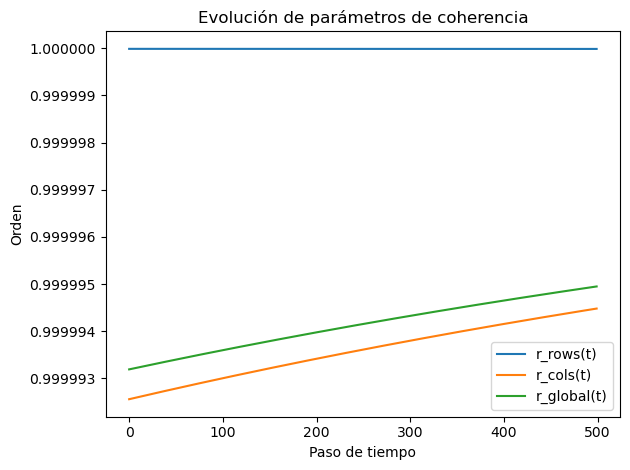

In [11]:
# ==============================
# Bloque 8: Parámetros de coherencia (sin notación científica/offset en el eje Y)
# ==============================
def order_parameter(phases):
    Z = np.exp(1j * phases)        # T x K
    r_t = np.abs(np.mean(Z, axis=1))
    return r_t

r_rows = order_parameter(traj_phi)
r_cols = order_parameter(traj_psi)
phases_global = np.concatenate([traj_phi, traj_psi], axis=1)  # T x (N+M)
r_global = order_parameter(phases_global)

summary = {
    "r_rows_mean": float(np.mean(r_rows)),
    "r_rows_final": float(r_rows[-1]),
    "r_cols_mean": float(np.mean(r_cols)),
    "r_cols_final": float(r_cols[-1]),
    "r_global_mean": float(np.mean(r_global)),
    "r_global_final": float(r_global[-1]),
    "N": int(traj_phi.shape[1]),
    "M": int(traj_psi.shape[1]),
    "K": float(K),
    "dt": float(dt),
    "T_total": float(T_total)
}
summary_df = pd.DataFrame([summary])
display(summary_df)

if SAVE_CSV:
    summary_df.to_csv(f"{SAVE_PREFIX}_coherence_summary.csv", index=False)
    print("Guardado:", f"{SAVE_PREFIX}_coherence_summary.csv")

# Gráfico
fig, ax = plt.subplots()
ax.plot(r_rows, label="r_rows(t)")
ax.plot(r_cols, label="r_cols(t)")
ax.plot(r_global, label="r_global(t)")
ax.set_xlabel("Paso de tiempo")
ax.set_ylabel("Orden")
ax.set_title("Evolución de parámetros de coherencia")
ax.legend()

# --- Desactivar offset y notación científica en Y ---
ax.ticklabel_format(axis='y', style='plain', useOffset=False)

# (Opcional recomendado) Limitar Y para que se vea el detalle sin offset:
ymin = float(min(r_rows.min(), r_cols.min(), r_global.min()))
ymax = float(max(r_rows.max(), r_cols.max(), r_global.max()))
pad = 0.05 * (ymax - ymin + 1e-12)
ax.set_ylim(ymin - pad, ymax + pad)

plt.tight_layout()
if SAVE_PNG:
    plt.savefig(f"{SAVE_PREFIX}_coherence.png", dpi=160)
plt.show()


In [ ]:
# ==============================
# Bloque 9:Selección automática de K_EMBED y N_ELEM_CLUSTERS por rejilla ===
# ==============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def standardized_features_from_UV_A(U_k, V_k, A):
    N, k1 = U_k.shape
    M, k2 = V_k.shape
    assert k1 == k2
    kk = k1
    feats = np.empty((N*M, 2*kk + 1), dtype=float)
    idx = 0
    for i in range(N):
        for j in range(M):
            feats[idx, :kk]      = U_k[i]
            feats[idx, kk:2*kk]  = V_k[j]
            feats[idx, -1]       = A[i, j]
            idx += 1
    mu = feats.mean(axis=0, keepdims=True)
    sigma = feats.std(axis=0, keepdims=True) + 1e-12
    return (feats - mu) / sigma

def kmeans_repeat(X, n_clusters, n_init=5, max_iter=60, random_state=0):
    rng = np.random.default_rng(random_state)
    best_labels = None
    best_centroids = None
    best_inertia = np.inf
    n_samples = X.shape[0]
    for _ in range(n_init):
        C = min(n_clusters, n_samples)
        centroids = X[rng.choice(n_samples, size=C, replace=False)]
        labels = np.zeros(n_samples, dtype=int)
        for _it in range(max_iter):
            d2 = ((X[:, None, :] - centroids[None, :, :])**2).sum(axis=2)
            new_labels = d2.argmin(axis=1)
            if np.array_equal(new_labels, labels):
                break
            labels = new_labels
            new_centroids = np.vstack([X[labels==c].mean(axis=0) if np.any(labels==c) else centroids[c]
                                       for c in range(C)])
            if np.allclose(new_centroids, centroids, atol=1e-6):
                centroids = new_centroids
                break
            centroids = new_centroids
        inertia = 0.0
        for c in range(n_clusters):
            m = (labels == c)
            if not np.any(m): 
                continue
            dif = X[m] - centroids[c]
            inertia += float((dif*dif).sum())
        if inertia < best_inertia:
            best_inertia  = inertia
            best_labels   = labels.copy()
            best_centroids= centroids.copy()
    return best_labels, best_centroids, best_inertia

def davies_bouldin_index(X, labels, centroids):
    C = centroids.shape[0]
    if C <= 1:
        return np.inf
    # dispersión intra
    S = np.zeros(C, dtype=float)
    for i in range(C):
        m = (labels == i)
        if not np.any(m):
            S[i] = 0.0
        else:
            dif = X[m] - centroids[i]
            S[i] = np.mean(np.sqrt((dif*dif).sum(axis=1)))
    # distancias entre centros
    M = np.sqrt(((centroids[:, None, :] - centroids[None, :, :])**2).sum(axis=2)) + 1e-12
    R = np.zeros((C, C), dtype=float)
    for i in range(C):
        for j in range(C):
            if i == j: 
                R[i, j] = -np.inf
            else:
                R[i, j] = (S[i] + S[j]) / M[i, j]
    return float(np.mean(R.max(axis=1)))

# --- SVD de la A_cross normalizada bipartita (recomendada para co-embeddings) ---
A = A_cross.astype(float)
N, M = A.shape
d_r = A.sum(axis=1); d_r[d_r==0] = 1e-12
d_c = A.sum(axis=0); d_c[d_c==0] = 1e-12
Dr_inv_sqrt = np.diag(1.0/np.sqrt(d_r))
Dc_inv_sqrt = np.diag(1.0/np.sqrt(d_c))
A_tilde = Dr_inv_sqrt @ A @ Dc_inv_sqrt

U, S, VT = np.linalg.svd(A_tilde, full_matrices=False)
sv2 = S**2
sv2_total = float(sv2.sum()) + 1e-12
cum_energy = np.cumsum(sv2) / sv2_total

# --- Rejilla ---
Kmax = min(min(N, M), 10)          # k hasta 10 o hasta rank
K_list = list(range(1, Kmax+1))
Cmax  = min(max(2, int(np.ceil(np.sqrt(N*M)))), 20)  # clusters de elementos hasta 20
C_list = list(range(2, Cmax+1))

# Para evitar costos altos, muestrear si hay demasiados elementos (pares i,j)
sample_cap = None
rng = np.random.default_rng(0)

results = []
best = None

def is_pref(r):  # preferimos K con energía SVD suficiente
    return r["sv_energy"] >= 0.85

for k in K_list:
    U_k = U[:, :k]
    V_k = VT[:k, :].T
    Xf = standardized_features_from_UV_A(U_k, V_k, A)

    # --- muestreo opcional ---
    if (sample_cap is not None) and (Xf.shape[0] > sample_cap):
        idx = rng.choice(Xf.shape[0], size=sample_cap, replace=False)
        X_eval = Xf[idx]
    else:
        X_eval = Xf

    for C in C_list:
        labels, centroids, inertia = kmeans_repeat(
            X_eval, n_clusters=C, n_init=5, max_iter=60, random_state=42
        )
        db = davies_bouldin_index(X_eval, labels, centroids)
        rec = {
            "K_embed": k,
            "C_elem": C,
            "db_index": db,
            "inertia": inertia,
            "sv_energy": float(cum_energy[k-1])
        }
        results.append(rec)

        if best is None:
            best = rec
        else:
            a, b = best, rec
            if is_pref(a) and not is_pref(b):
                pass
            elif not is_pref(a) and is_pref(b):
                best = b
            else:
                if b["db_index"] < a["db_index"] - 1e-9:
                    best = b
                elif abs(b["db_index"] - a["db_index"]) <= 1e-9 and b["inertia"] < a["inertia"] - 1e-9:
                    best = b

scores_df = pd.DataFrame(results)
display(scores_df.head())
scores_df.to_csv(f"{SAVE_PREFIX}_grid_scores.csv", index=False)
print("Guardado:", f"{SAVE_PREFIX}_grid_scores.csv")
print("Sugerencia óptima -> K_EMBED =", best["K_embed"], 
      ", N_ELEM_CLUSTERS =", best["C_elem"],
      ", DB =", round(best["db_index"],4), 
      ", energía SVD =", round(best["sv_energy"],3))

# Heatmap DB-index (K vs C)
pivot = scores_df.pivot(index="K_embed", columns="C_elem", values="db_index")
plt.figure()
im = plt.imshow(pivot.values, aspect="auto", origin="lower")
plt.xticks(range(pivot.shape[1]), pivot.columns)
plt.yticks(range(pivot.shape[0]), pivot.index)
plt.colorbar(im, label="Davies–Bouldin (menor es mejor)")
plt.xlabel("N_ELEM_CLUSTERS (C)")
plt.ylabel("K_EMBED (K)")
plt.title("Grid DB-index (K vs C)")
# marca el mejor
try:
    bi = K_list.index(best["K_embed"])
    bj = C_list.index(best["C_elem"])
    plt.scatter([bj], [bi], marker="x")
except Exception:
    pass
plt.tight_layout()
plt.savefig(f"{SAVE_PREFIX}_grid_dbindex.png", dpi=160)
plt.show()
print("Figura guardada:", f"{SAVE_PREFIX}_grid_dbindex.png")


In [18]:
# ============================================================
# Bloque 10: REPLICABILIDAD del selector del Bloque 9
#   - Test A: misma semilla => resultado idéntico (bit a bit)
#   - Test B: semillas distintas => sensibilidad al muestreo (sample_cap)
#
# Requiere en memoria (idéntico a Bloque 9):
#   - A_cross
#   - standardized_features_from_UV_A, kmeans_repeat, davies_bouldin_index
# ============================================================

import numpy as np
import pandas as pd

def grid_best_block9(A_cross, sample_cap=8000, rng_seed=0,
                     Kmax_cap=10, Cmax_cap=20, kmeans_state=42):
    # --- (1) A y normalización bipartita: IGUAL al Bloque 9 ---
    A = A_cross.astype(float)
    N, M = A.shape
    d_r = A.sum(axis=1); d_r[d_r == 0] = 1e-12
    d_c = A.sum(axis=0); d_c[d_c == 0] = 1e-12
    Dr_inv_sqrt = np.diag(1.0/np.sqrt(d_r))
    Dc_inv_sqrt = np.diag(1.0/np.sqrt(d_c))
    A_tilde = Dr_inv_sqrt @ A @ Dc_inv_sqrt

    # --- (2) SVD: IGUAL ---
    U, S, VT = np.linalg.svd(A_tilde, full_matrices=False)
    sv2 = S**2
    sv2_total = float(sv2.sum()) + 1e-12
    cum_energy = np.cumsum(sv2) / sv2_total

    # --- (3) Rejilla: IGUAL ---
    Kmax = min(min(N, M), Kmax_cap)
    K_list = list(range(1, Kmax+1))
    Cmax = min(max(2, int(np.ceil(np.sqrt(N*M)))), Cmax_cap)
    C_list = list(range(2, Cmax+1))

    rng = np.random.default_rng(rng_seed)

    def is_pref(rec):
        return rec["sv_energy"] >= 0.85

    results = []
    best = None

    # --- (4) Loop idéntico al Bloque 9 ---
    for k in K_list:
        U_k = U[:, :k]
        V_k = VT[:k, :].T

        # standardized_features_from_UV_A: IGUAL (incluye estandarización global)
        Xf = standardized_features_from_UV_A(U_k, V_k, A)

        # muestreo opcional: IGUAL (ojo con sample_cap None)
        if (sample_cap is not None) and (Xf.shape[0] > sample_cap):
            idx = rng.choice(Xf.shape[0], size=sample_cap, replace=False)
            X_eval = Xf[idx]
        else:
            X_eval = Xf

        for C in C_list:
            labels, centroids, inertia = kmeans_repeat(
                X_eval, n_clusters=C, n_init=5, max_iter=60, random_state=kmeans_state
            )
            db = davies_bouldin_index(X_eval, labels, centroids)

            rec = {
                "K_embed": int(k),
                "C_elem": int(C),
                "db_index": float(db),
                "inertia": float(inertia),
                "sv_energy": float(cum_energy[k-1]),
            }
            results.append(rec)

            if best is None:
                best = rec
            else:
                a, b = best, rec
                if is_pref(a) and not is_pref(b):
                    pass
                elif not is_pref(a) and is_pref(b):
                    best = b
                else:
                    if b["db_index"] < a["db_index"] - 1e-9:
                        best = b
                    elif abs(b["db_index"] - a["db_index"]) <= 1e-9 and b["inertia"] < a["inertia"] - 1e-9:
                        best = b

    scores_df = pd.DataFrame(results)
    return best, scores_df


# ----------------------------
# CONFIG
# ----------------------------
N_REPEATS_SAMESEED = 5
N_REPEATS_DIFFSEED = 10
SAMPLE_CAP = None
FIXED_SEED = 0
KMEANS_STATE = 42

# ----------------------------
# Test A: misma semilla => debe ser idéntico
# ----------------------------
best0, df0 = grid_best_block9(A_cross, sample_cap=SAMPLE_CAP, rng_seed=FIXED_SEED, kmeans_state=KMEANS_STATE)
df0s = df0.sort_values(["K_embed","C_elem"]).reset_index(drop=True)
h0 = pd.util.hash_pandas_object(df0s[["K_embed","C_elem","db_index","inertia","sv_energy"]], index=False).sum()

bests_A = []
hashes_A = []

for r in range(N_REPEATS_SAMESEED):
    bestA, dfA = grid_best_block9(A_cross, sample_cap=SAMPLE_CAP, rng_seed=FIXED_SEED, kmeans_state=KMEANS_STATE)
    dfAs = dfA.sort_values(["K_embed","C_elem"]).reset_index(drop=True)
    hA = pd.util.hash_pandas_object(dfAs[["K_embed","C_elem","db_index","inertia","sv_energy"]], index=False).sum()

    bests_A.append((bestA["K_embed"], bestA["C_elem"], bestA["db_index"], bestA["inertia"]))
    hashes_A.append(int(hA))

print("TEST A (misma semilla):")
print(" - baseline best:", (best0["K_embed"], best0["C_elem"], best0["db_index"], best0["inertia"]))
print(" - bests:", bests_A)
print(" - hashes:", hashes_A)
print(" - ¿idéntico a baseline? ->", (all(h == int(h0) for h in hashes_A) and all(b == bests_A[0] for b in bests_A)))

# ----------------------------
# Test B: semillas distintas => sensibilidad al muestreo
# ----------------------------
records_B = []
for s in range(N_REPEATS_DIFFSEED):
    seed = FIXED_SEED + 1000 + s
    bestB, _ = grid_best_block9(A_cross, sample_cap=SAMPLE_CAP, rng_seed=seed, kmeans_state=KMEANS_STATE)
    records_B.append({
        "rng_seed": int(seed),
        "K_best": int(bestB["K_embed"]),
        "C_best": int(bestB["C_elem"]),
        "DB_best": float(bestB["db_index"]),
        "inertia_best": float(bestB["inertia"]),
        "sv_energy_best": float(bestB["sv_energy"]),
    })

resB = pd.DataFrame(records_B)
print("\nTEST B (semillas distintas): frecuencia de (K*,C*):")
display(resB.groupby(["K_best","C_best"]).size().reset_index(name="count").sort_values("count", ascending=False))
display(resB)


TEST A (misma semilla):
 - baseline best: (5, 2, 0.11444390661380616, 85626.17492128747)
 - bests: [(5, 2, 0.11444390661380616, 85626.17492128747), (5, 2, 0.11444390661380616, 85626.17492128747), (5, 2, 0.11444390661380616, 85626.17492128747), (5, 2, 0.11444390661380616, 85626.17492128747), (5, 2, 0.11444390661380616, 85626.17492128747)]
 - hashes: [8668305388662194067, 8668305388662194067, 8668305388662194067, 8668305388662194067, 8668305388662194067]
 - ¿idéntico a baseline? -> True

TEST B (semillas distintas): frecuencia de (K*,C*):


,K_best,C_best,count
0,1,3,7
2,2,3,2
1,1,15,1


,rng_seed,K_best,C_best,DB_best,inertia_best,sv_energy_best
0,1000,1,3,0.333668,1690.900287,1.0
1,1001,1,3,0.347946,1759.277673,1.0
2,1002,1,3,0.315958,1509.831102,1.0
3,1003,1,3,0.316016,1565.429258,1.0
4,1004,2,3,0.354634,6499.975294,1.0
5,1005,1,3,0.351907,1721.776340,1.0
6,1006,1,3,0.331308,1564.985927,1.0
7,1007,1,3,0.352227,1796.891570,1.0
8,1008,1,15,0.437212,105.210004,1.0
9,1009,2,3,0.352208,5462.939452,1.0



## Bloque extra: **Clustering de ELEMENTOS** de `A_cross`

Agrupa cada **par (i,j)** (elemento de la matriz cruzada) usando un embedding bipartito (SVD de la afinidad normalizada) y **k-means** sobre el vector concatenado \([U_k(i,:), V_k(j,:), A_{ij}]\).
Genera:
- Gráfico de tamaños de grupos
- CSV `kuramoto_bipartito_element_clusters.csv` con columnas: `row_i, col_j, cluster, X_value, A_cross_value`
- Impresión de listas por cluster: `(i,j) -> X[i,j], A_cross[i,j]`


Usando selección óptima -> K_EMBED = 1 , N_ELEM_CLUSTERS = 3


,row_i,col_j,cluster,X_value,A_cross_value
0,0,0,2,354.0,1.000000
1,0,1,1,817.0,0.999866
2,0,2,2,50.0,0.999997
3,0,3,1,31.0,0.999848
4,0,4,2,448.0,1.000000


Guardado: kuramoto_bipartito_element_clusters.csv
Tamaños por cluster:
cluster
0      23675
1     143545
2    1922238
Name: count, dtype: int64


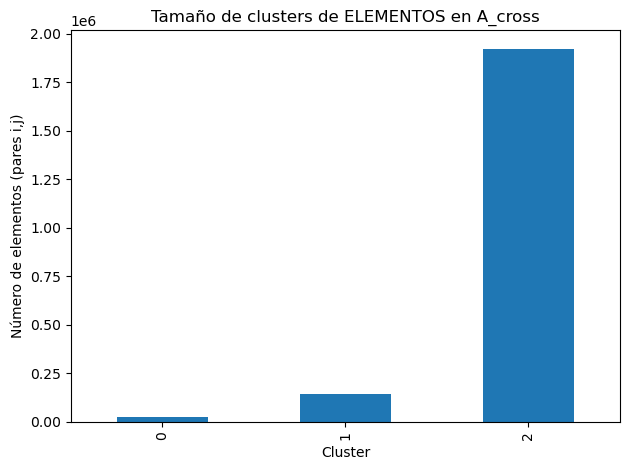

\nCluster 0 (n=23675):
 (i=249.0, j=0.0) -> X=2732, A_cross=1.0000
 (i=249.0, j=1.0) -> X=4.186e+04, A_cross=0.9999
 (i=249.0, j=2.0) -> X=1384, A_cross=1.0000
 (i=249.0, j=4.0) -> X=92, A_cross=1.0000
 (i=249.0, j=6.0) -> X=89, A_cross=1.0000
 (i=249.0, j=7.0) -> X=17, A_cross=1.0000
 (i=249.0, j=8.0) -> X=1.634e+04, A_cross=1.0000
 (i=249.0, j=9.0) -> X=1, A_cross=1.0000
 (i=249.0, j=10.0) -> X=0, A_cross=1.0000
 (i=249.0, j=11.0) -> X=2, A_cross=1.0000
 (i=249.0, j=12.0) -> X=0, A_cross=1.0000
 (i=249.0, j=13.0) -> X=9, A_cross=1.0000
 (i=249.0, j=14.0) -> X=1, A_cross=1.0000
 (i=249.0, j=15.0) -> X=47, A_cross=1.0000
 (i=249.0, j=16.0) -> X=280, A_cross=1.0000
 (i=249.0, j=17.0) -> X=47, A_cross=1.0000
 (i=249.0, j=18.0) -> X=260, A_cross=1.0000
 (i=249.0, j=19.0) -> X=10, A_cross=1.0000
 (i=249.0, j=20.0) -> X=17, A_cross=1.0000
 (i=249.0, j=21.0) -> X=39, A_cross=1.0000
 (i=249.0, j=22.0) -> X=2, A_cross=1.0000
 (i=249.0, j=23.0) -> X=229, A_cross=1.0000
 (i=249.0, j=24.0) -> X=4

In [14]:

# ==============================
# Clustering de ELEMENTOS (i,j) de A_cross
# ==============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def element_pair_clustering(A_nm, X_original, n_elem_clusters=6, k_embed=6, random_state=0, max_iter=60):
    A = np.asarray(A_nm, dtype=float)
    N, M = A.shape

    # --- Normalización bipartita D_r^{-1/2} A D_c^{-1/2}
    d_r = A.sum(axis=1); d_r[d_r==0] = 1e-12
    d_c = A.sum(axis=0); d_c[d_c==0] = 1e-12
    Dr_inv_sqrt = np.diag(1.0/np.sqrt(d_r))
    Dc_inv_sqrt = np.diag(1.0/np.sqrt(d_c))
    A_tilde = Dr_inv_sqrt @ A @ Dc_inv_sqrt

    # --- SVD truncada
    U, S, VT = np.linalg.svd(A_tilde, full_matrices=False)
    kk = int(min(k_embed, U.shape[1], VT.shape[0]))
    if kk < 1:
        kk = 1
    U_k = U[:, :kk]      # N x kk
    V_k = VT[:kk, :].T   # M x kk

    # --- Construir features por elemento (i,j): [U_k(i,:), V_k(j,:), A_ij]
    feats = np.empty((N*M, 2*kk + 1), dtype=float)
    coords = np.empty((N*M, 2), dtype=int)
    idx = 0
    for i in range(N):
        for j in range(M):
            feats[idx, :kk] = U_k[i, :]
            feats[idx, kk:2*kk] = V_k[j, :]
            feats[idx, -1] = A[i, j]  # valor de afinidad
            coords[idx, 0] = i
            coords[idx, 1] = j
            idx += 1

    # --- Estandarizar features
    mu = feats.mean(axis=0, keepdims=True)
    sigma = feats.std(axis=0, keepdims=True) + 1e-12
    Xf = (feats - mu) / sigma

    # --- k-means minimalista
    rng = np.random.default_rng(random_state)
    C = min(n_elem_clusters, Xf.shape[0])
    centroids = Xf[rng.choice(Xf.shape[0], size=C, replace=False)]
    labels = np.zeros(Xf.shape[0], dtype=int)

    for _ in range(max_iter):
        d2 = ((Xf[:, None, :] - centroids[None, :, :])**2).sum(axis=2)  # (NM) x C
        new_labels = d2.argmin(axis=1)
        if np.array_equal(new_labels, labels):
            break
        labels = new_labels
        new_centroids = np.vstack([Xf[labels==c].mean(axis=0) if np.any(labels==c) else centroids[c]
                                   for c in range(C)])
        if np.allclose(new_centroids, centroids, atol=1e-6):
            centroids = new_centroids
            break
        centroids = new_centroids

    # --- Construir DataFrame de salida
    out = []
    for idx, (i, j) in enumerate(coords):
        out.append({
            "row_i": int(i),
            "col_j": int(j),
            "cluster": int(labels[idx]),
            "X_value": float(X_original[i, j]) if (i < X_original.shape[0] and j < X_original.shape[1]) else np.nan,
            "A_cross_value": float(A[i, j]),
        })
    df = pd.DataFrame(out)
    return df

# Parámetros del usuario (ajustables)
N_ELEM_CLUSTERS = int(best["C_elem"])
K_EMBED         = int(best["K_embed"])
RANDOM_STATE    = 0
print("Usando selección óptima ->",
      "K_EMBED =", K_EMBED, ", N_ELEM_CLUSTERS =", N_ELEM_CLUSTERS)


# Ejecutar clustering de elementos sobre A_cross
df_elems = element_pair_clustering(A_cross, X, n_elem_clusters=N_ELEM_CLUSTERS, k_embed=K_EMBED, random_state=RANDOM_STATE)
display(df_elems.head())

# Guardar CSV
csv_path = f"Resultados_Bipartito/{SAVE_PREFIX}_element_clusters.csv"
df_elems.to_csv(csv_path, index=False)
print("Guardado:", csv_path)

# Resumen de tamaños por cluster
sizes = df_elems["cluster"].value_counts().sort_index()
print("Tamaños por cluster:")
print(sizes)

# Gráfico: barras de tamaños
plt.figure()
sizes.sort_index().plot(kind="bar")
plt.xlabel("Cluster")
plt.ylabel("Número de elementos (pares i,j)")
plt.title("Tamaño de clusters de ELEMENTOS en A_cross")
plt.tight_layout()
if SAVE_PNG:
    plt.savefig(f"{SAVE_PREFIX}_element_cluster_sizes.png", dpi=160)
plt.show()

# Listado por cluster (coordenadas y valores)
max_per_cluster_to_print = 50  # por si NM es grande
for c in sorted(df_elems["cluster"].unique()):
    sub = df_elems[df_elems["cluster"]==c]
    print(f"\\nCluster {c} (n={len(sub)}):")
    for _, r in sub.head(max_per_cluster_to_print).iterrows():
        print(f" (i={r['row_i']}, j={r['col_j']}) -> X={r['X_value']:.4g}, A_cross={r['A_cross_value']:.4f}")
    if len(sub) > max_per_cluster_to_print:
        print(f" ... (+{len(sub)-max_per_cluster_to_print} más)")
